# Linear Regression
Linear regression describe different methods which assume a linear relationship between X and Y and try to predict, infer and classify based on this assumption. 

The most simple model is described by

$$
Y = \beta_0 + \beta_1 X
$$

where X is the observation data and Y is the target variable. $\beta_0$ describes the intercept and $\beta_1$ describes the slope. 

## Estimating the coefficients

For a given train dataset X and Y we want to estimate the parameters $\beta$ to find the function f which connects X and Y or describe the relationship between X and Y. To estimate the parameters search for parameters which minimize the sum of residual errors. 
The minimizers are 
$$
\hat \beta_1 = \frac{\Sigma(x_i - \overline x)(y_i - \overline y)}{\Sigma(x_i - \overline x)^2}
$$
and
$$
\hat \beta_0 = \overline y - \hat \beta_1 \overline x
$$

## Assessing the accuracy of the coefficient estimates

Recalling Y = f(X) + E where E is a mean zero random error term. Now we want to assess the accuracy of the fit. To assess this we need to compare our fit from the train set to the underlying ground truth functional relationship the so called population fit line.


Estimated coefficients:
Intercept: 1.6543742918452504, Slope: 3.0275865346733126


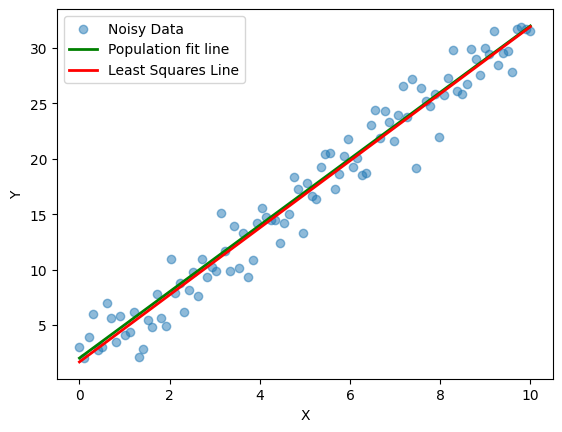

In [55]:
## Example Code
import numpy as np
import matplotlib.pyplot as plt

# Generate a test dataset
# Functional relationship Y = 2 + 3X
X_test = np.linspace(0, 10, 100)
Y_test = 2 + 3*X_test + np.random.normal(0, 2, 100)
Y_true = 2 + 3*X_test

# Fit a simple linear regression model using Least Squares
A = np.vstack([np.ones(len(X_test)), X_test]).T
coefficients = np.linalg.lstsq(A, Y_test, rcond=None)[0]

print("Estimated coefficients:")
print(f"Intercept: {coefficients[0]}, Slope: {coefficients[1]}")

# Plot the results
plt.scatter(X_test, Y_test, label='Noisy Data', alpha=0.5)
plt.plot(X_test, Y_true, 'g', label='Population fit line', linewidth=2)
plt.plot(X_test, A @ coefficients, 'r', label='Least Squares Line', linewidth=2)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

The green kine shows the population fit and the red line the least squares fit. It differs as the prediction from the noisy data points contain the irredicible error E. 

We assume that the least square predictor is an unbiased predictor, meaning that if we take always a subsample of the datapoints as trainingdataset or different subsamples we always get an estimate of the bias term $\hat \beta_0$ or intercept that will be around the true bias term $\beta_0$. Therefor if we have a huge number of samples and subsample them a lot of times and observe the estimated intercept we will come close to the true bias term. This also holds for the different parameters $\beta$

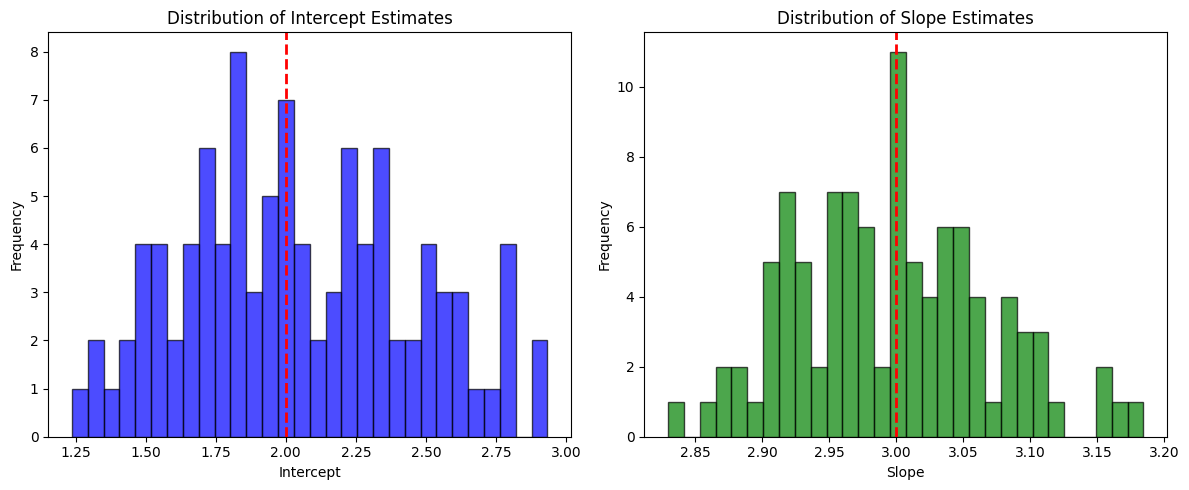

Mean estimated intercept: 2.0450647206256076
Mean estimated slope: 2.9960986618048495
True intercept: 2
True slope: 3
Error in intercept estimate: 0.045064720625607624
Error in slope estimate: -0.0039013381951504833


In [56]:
## make now a MC simulation to show how the LS estimator behaves with different sample sizes and how the parameters vary around the true parameters
import numpy as np
import matplotlib.pyplot as plt

def model(X):
    return 2 + 3 * X

def subsample_and_fit(n_samples, n_subsamples=100):
    intercepts = []
    slopes = []
    for _ in range(n_subsamples):
        X = np.random.uniform(0, 10, n_samples)
        Y = model(X) + np.random.normal(0, 2, n_samples)
        
        A = np.vstack([np.ones(len(X)), X]).T
        coeffs = np.linalg.lstsq(A, Y, rcond=None)[0]
        
        intercepts.append(coeffs[0])
        slopes.append(coeffs[1])
    
    return np.array(intercepts), np.array(slopes)

sample_size = 100 
intercepts, slopes = subsample_and_fit(sample_size)

# Plot the distribution of the estimated parameters
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(intercepts, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(2, color='red', linestyle='dashed', linewidth=2)
plt.title('Distribution of Intercept Estimates')
plt.xlabel('Intercept')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(slopes, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.axvline(3, color='red', linestyle='dashed', linewidth=2)
plt.title('Distribution of Slope Estimates')
plt.xlabel('Slope')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Mean estimated intercept:", np.mean(intercepts))
print("Mean estimated slope:", np.mean(slopes))
print("True intercept: 2")
print("True slope: 3")
print("Error in intercept estimate:", np.mean(intercepts) - 2)
print("Error in slope estimate:", np.mean(slopes) - 3)

From the MC analysis we can see that we reach over successive model fittings over a sequence of subsets of the training dataset a close to population fit parameters which show that the random normal distributed error averages out and our unbiased estimator does not systematically over or underestimates the parameters of the function f. This observation is comparable to estimation of the mean of a normal distributed dataset. 

One typical question is how close is a single estimation to the population fit line or how robust is our estimation? 

Here we can calculate the standard error SE which also refers to the variance 

$$
Var(\hat \mu) = SE(\hat \mu ^2) = \sigma ^2 / n
$$
where $\sigma$ is the standard deviation of each of the realizations of y or $Y^2$. Recalling Y = $\beta X + E$ and assume that our estimator is bias free the variance of Y directly depends on the introduced ireducable error E.

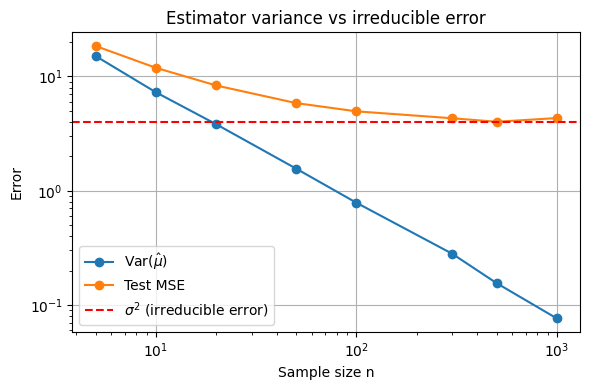

In [57]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# True model
def f(x):
    return 2 + 3 * x

sigma = 2.0          # irreducible error (noise std)
sigma2 = sigma**2

n_repeats = 500
sample_sizes = [5, 10, 20, 50, 100, 300, 500, 1000]

var_mu_hat = []
test_mse = []

for n in sample_sizes:
    mu_hats = []
    mse_list = []

    for _ in range(n_repeats):
        X = np.random.uniform(0, 10, n)
        eps = np.random.normal(0, sigma, n)
        Y = f(X) + eps

        # estimate mean of Y
        mu_hat = np.mean(Y)
        mu_hats.append(mu_hat)

        # test error at a fixed x0
        x0 = 5.0
        y0 = f(x0) + np.random.normal(0, sigma)
        mse_list.append((mu_hat - y0)**2)

    var_mu_hat.append(np.var(mu_hats))
    test_mse.append(np.mean(mse_list))

# Plot
plt.figure(figsize=(6,4))
plt.plot(sample_sizes, var_mu_hat, marker='o', label=r'$\operatorname{Var}(\hat\mu)$')
plt.plot(sample_sizes, test_mse, marker='o', label='Test MSE')
plt.axhline(sigma2, color='red', linestyle='--', label=r'$\sigma^2$ (irreducible error)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Sample size n')
plt.ylabel('Error')
plt.title('Estimator variance vs irreducible error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


The variance of an estimator (e.g. $\operatorname{Var}(\hat\mu)$) measures uncertainty due to finite samples.
It decreases as the sample size increases.

The irreducible error, however, is given by
$$
\sigma^2 = \operatorname{Var}(\varepsilon),
$$
and represents intrinsic noise in the data-generating process.
No increase in sample size or model complexity can reduce this component.

In the simulation above, $\operatorname{Var}(\hat\mu)$ tends to zero,
while the test mean squared error converges to $\sigma^2$,
illustrating the concept of irreducible error.


If we now want to assess the accuracy of the coefficient estimate, we can calculate the residual standard error, which is the residual stabdard error RSE from the Residual Squared Error RSS using 

$$
RSE = \sqrt{RSS /(1/n)} 
$$

where we used bootstrapping to estimate the parameters of $\beta$ from a sequence of bootstrapped fits. 

Based on the standard error we can calculate the 95% confidence interval, which states that with a 95% confidence the true parameters of the population fit line are within the parameter ranges of $\beta$.

Therefor we can say that 

$$ 
[\hat \beta_1 - 2SE(\hat \beta_1), \hat \beta_1 + 2SE(\hat \beta_1)]
$$

is our 95 % confidence interval and within this interval the true value of $\beta_1$ is contained.

We can also use the standard errors SE to perform hypothesis tests and could test the 0 hypothesis :

- "H0: There is no relationship between X and Y"

versus the alternative hypothesis 

- "Ha : There is some relation between X and Y"

Recalling the relationship between X and Y

$$
Y = \beta_0 + \beta_1 X + E

$$

H0: $\beta_1$ = 0 

H1: $\beta_1 != 0$

means if the nullhypothesis holds the slope parameter does not have any influence on Y over X and the function reduces to Y = $\beta_0$ + E

To be sure that the Nullhypothesis is wrong we need to verify that $\beta_1$ is sufficient far away from 0 and thus there is a relationship between X and Y. Here a t-statistic can be used. The t-statistic measures how many standard errors an estimate is away from the null value. 

In linear regression, the test statistic for a coefficient is

$$
t = \frac{\hat\beta_1}{\operatorname{SE}(\hat\beta_1)}.
$$

Under the null hypothesis $H_0: \beta_1 = 0$ and assuming normally distributed errors E,
this statistic follows a Student-$t$ distribution with

$$
n - p
$$

with n degrees of freedom, and p = 2 since two parameters ($\beta_0$ and $\beta_1$) are estimated.

As the sample size n increases, the Student-$t$ distribution converges to a standard  normal distribution. For degrees of freedom larger than about 30, the normal approximation is typically very accurate.

## Student's t-distribution

The probability density function (pdf) of the Student's t-distribution with
$\nu > 0$ degrees of freedom is

$$
f(t \mid \nu)
=
\frac{\Gamma\!\left(\frac{\nu+1}{2}\right)}
     {\sqrt{\nu\pi}\,\Gamma\!\left(\frac{\nu}{2}\right)}
\left(1 + \frac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}},
$$

where:
- $t \in \mathbb{R}$ is the value of the random variable,
- $\nu$ is the number of degrees of freedom,
- $\Gamma(\cdot)$ denotes the Gamma function.

#- Mean: $0$ for $\nu > 1$
- Variance: $\frac{\nu}{\nu - 2}$ for $\nu > 2$
- Symmetric around $0$
- Heavier tails than the standard normal distribution

As the degrees of freedom increase,
the Student's t-distribution converges to the standard normal distribution:

$$
t_\nu \xrightarrow[\nu \to \infty]{} \mathcal{N}(0,1).
$$


## p-values, t-statistic, and hypothesis testing

The p-value is defined as
$$
p = \Pr\left(|T| \ge |t_{\text{obs}}| \mid H_0\right),
$$
i.e. the probability of observing a t-statistic at least as extreme as the one obtained,
*assuming the null hypothesis is true*.

In linear regression, the null hypothesis
$$
H_0: \beta_1 = 0
$$
is tested using the t-statistic
$$
t = \frac{\hat\beta_1}{\operatorname{SE}(\hat\beta_1)},
$$
which follows a Student-$t$ distribution with
$$
n - 2
$$
degrees of freedom.

A p-value below a chosen significance level $\alpha$ (e.g. $0.05$)
leads to rejection of $H_0$.


In [58]:
### Hypothesis Testing Example on the advertising dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# wont be used here but useful for regression analysis
import statsmodels.api as sm
from statsmodels.formula.api import ols

data = pd.read_csv('data/Advertising.csv', index_col=0)

# Display the first few rows of the dataset
print(data.head(5))

# we want to test if TV advertising has a significant effect on sales
# Therefore TV is the predictor variable and Sales the response variable
# Null Hypothesis H0: There is no effect of TV advertising on sales (slope
# Alternative Hypothesis H1: There is an effect of TV advertising on sales (slope != 0)

# 1. Fit the linear regression model

X = data['TV']
y = data['sales']

# model Y = beta_0 + beta_1 * X + epsilon -- least squares fit
# design matrix
A = np.vstack([np.ones(len(X)), X]).T
coefficients, residuals, rank, s = np.linalg.lstsq(A, y, rcond=None)
beta_0, beta_1 = coefficients
print(f"Fitted model: Sales = {beta_0:.4f} + {beta_1:.4f} * TV")

# 2. Calculate the standard error of the slope coefficient
n = len(X)
y_pred = beta_0 + beta_1 * X
residuals = y - y_pred 
rss = np.sum(residuals**2) 
sigma_squared = rss / (n) # 3.7
se_beta_1 = np.sqrt(sigma_squared / np.sum((X - np.mean(X))**2)) # 3.8
se_beta_0 = np.sqrt(sigma_squared * (1/n + (np.mean(X)**2) / np.sum((X - np.mean(X))**2))) # 3.8
print(f"Standard error of the slope coefficient: {se_beta_1:.4f}")
print(f"Standard error of the intercept coefficient: {se_beta_0:.4f}")

# 3. Compute the t-statistic for the slope coefficient beta_1
t_statistic = (beta_1 - 0) / se_beta_1 # 3.14
print(f"t-statistic for the slope coefficient: {t_statistic:.4f}")

# 4. Determine the critical t-value for a two-tailed test at alpha = 0.05
from scipy.stats import t

# 4.1 determine the p-value for alpha = 0.05 
p_value = (1 - t.cdf(np.abs(t_statistic), df=n-2)) * 2
print(f"p-value for the slope coefficient: {p_value:.4f}")
alpha = 0.05
critical_t = t.ppf(1 - alpha/2, df=n-2)
print(f"Critical t-value for alpha = {alpha}: ±{critical_t:.4f}")  

# 5. Make a decision
if np.abs(t_statistic) > critical_t:
    print("Reject the null hypothesis: There is a significant effect of TV advertising on sales.")
else:
    print("Fail to reject the null hypothesis: There is no significant effect of TV advertising on sales.") 
    



      TV  radio  newspaper  sales
1  230.1   37.8       69.2   22.1
2   44.5   39.3       45.1   10.4
3   17.2   45.9       69.3    9.3
4  151.5   41.3       58.5   18.5
5  180.8   10.8       58.4   12.9
Fitted model: Sales = 7.0326 + 0.0475 * TV
Standard error of the slope coefficient: 0.0027
Standard error of the intercept coefficient: 0.4555
t-statistic for the slope coefficient: 17.7566
p-value for the slope coefficient: 0.0000
Critical t-value for alpha = 0.05: ±1.9720
Reject the null hypothesis: There is a significant effect of TV advertising on sales.


In [59]:
# now write a function which does the fitting and returns the parameters
    
from scipy.stats import t
import numpy as np
import pandas as pd
def fit_linear_regression(X, Y):
    A = np.vstack([np.ones(len(X)), X]).T
    coefficients = np.linalg.lstsq(A, Y, rcond=None)[0]
    return coefficients

# now calculate the standard error of the estimators

def calculate_standard_error(X, Y, coefficients):
    Y_hat = coefficients[0] + coefficients[1] * X
    residuals = Y - Y_hat
    n = len(Y)
    rss = np.sum(residuals**2)
    sigma_squared = rss / n
    se_beta_1 = np.sqrt(sigma_squared / np.sum((X - np.mean(X))**2))
    se_beta_0 = np.sqrt(sigma_squared * (1/n + (np.mean(X)**2) / np.sum((X - np.mean(X))**2)))
    return se_beta_0, se_beta_1

# now calculate the t-statistic for the slope coefficient

def calculate_t_statistic(beta_1, se_beta_1):
    # Null hypothesis: beta_1 = 0
    t_statistic = (beta_1 - 0) / se_beta_1
    return t_statistic

def calculate_p_value(t_statistic, n):
    from scipy.stats import t
    p_value = (1 - t.cdf(np.abs(t_statistic), df=n-2)) * 2
    return p_value

def hypothesis_test(X, Y, alpha=0.05):
    coefficients = fit_linear_regression(X, Y)
    beta_0, beta_1 = coefficients
    se_beta_0, se_beta_1 = calculate_standard_error(X, Y, coefficients)
    t_statistic = calculate_t_statistic(beta_1, se_beta_1)
    n = len(Y)
    p_value = calculate_p_value(t_statistic, n)

    critical_t = t.ppf(1 - alpha/2, df=n-2)
    
    print(f"Fitted model: Y = {beta_0:.4f} + {beta_1:.4f} * X")
    print(f"Standard error of the slope coefficient: {se_beta_1:.4f}")
    print(f"t-statistic for the slope coefficient: {t_statistic:.4f}")
    print(f"p-value for the slope coefficient: {p_value:.4f}")
    print(f"Critical t-value for alpha = {alpha}: ±{critical_t:.4f}")  
    
    if np.abs(t_statistic) > critical_t:
        print("Reject the null hypothesis: There is a significant effect.")
    else:
        print("Fail to reject the null hypothesis: There is no significant effect.")
        
# now try it on the advertising dataset
data = pd.read_csv('data/Advertising.csv', index_col=0)
X = data['TV']
y = data['sales']
hypothesis_test(X, y, alpha=0.05)
# now on newspaper
X = data['newspaper']
y = data['sales']
hypothesis_test(X, y, alpha=0.05)

# now on radio
X = data['radio']
y = data['sales']
hypothesis_test(X, y, alpha=0.05)
    
        

Fitted model: Y = 7.0326 + 0.0475 * X
Standard error of the slope coefficient: 0.0027
t-statistic for the slope coefficient: 17.7566
p-value for the slope coefficient: 0.0000
Critical t-value for alpha = 0.05: ±1.9720
Reject the null hypothesis: There is a significant effect.
Fitted model: Y = 12.3514 + 0.0547 * X
Standard error of the slope coefficient: 0.0165
t-statistic for the slope coefficient: 3.3162
p-value for the slope coefficient: 0.0011
Critical t-value for alpha = 0.05: ±1.9720
Reject the null hypothesis: There is a significant effect.
Fitted model: Y = 9.3116 + 0.2025 * X
Standard error of the slope coefficient: 0.0203
t-statistic for the slope coefficient: 9.9707
p-value for the slope coefficient: 0.0000
Critical t-value for alpha = 0.05: ±1.9720
Reject the null hypothesis: There is a significant effect.


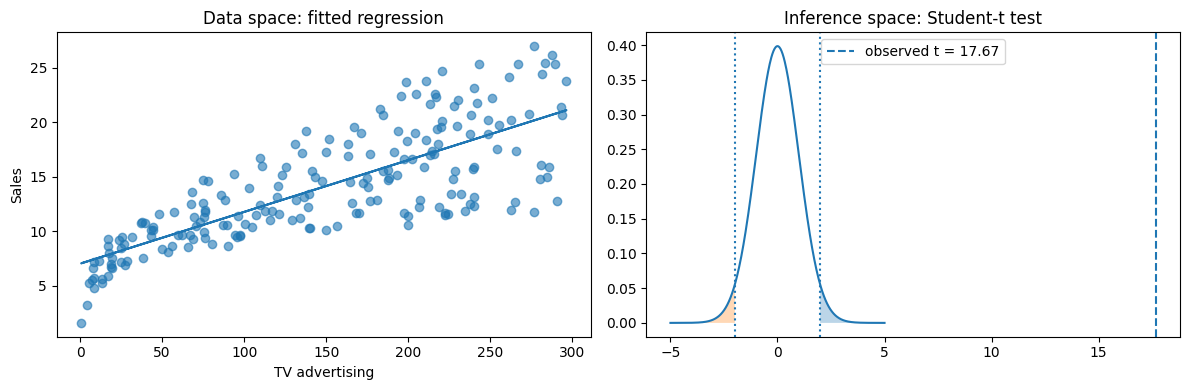

beta_1 estimate  : 0.0475
SE(beta_1)       : 0.0027
t-statistic      : 17.67
critical t       : ±1.97
p-value          : 0.00e+00


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# -----------------------------
# 1. Load data
# -----------------------------
data = pd.read_csv("data/Advertising.csv", index_col=0)
X = data["TV"].values
y = data["sales"].values
n = len(X)

# -----------------------------
# 2. Fit linear regression (DATA SPACE)
# -----------------------------
A = np.vstack([np.ones(n), X]).T
beta_0, beta_1 = np.linalg.lstsq(A, y, rcond=None)[0]

y_hat = beta_0 + beta_1 * X
residuals = y - y_hat

# Estimate noise variance
RSS = np.sum(residuals**2)
sigma2 = RSS / (n - 2)

# Standard error of slope
SE_beta1 = np.sqrt(sigma2 / np.sum((X - X.mean())**2))

# -----------------------------
# 3. Hypothesis test (INFERENCE SPACE)
# -----------------------------
t_stat = beta_1 / SE_beta1
alpha = 0.05
df = n - 2
critical_t = t.ppf(1 - alpha/2, df)
p_value = 2 * (1 - t.cdf(abs(t_stat), df))

# -----------------------------
# 4. Visualization
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) Data space: regression
axes[0].scatter(X, y, alpha=0.6)
axes[0].plot(X, y_hat)
axes[0].set_xlabel("TV advertising")
axes[0].set_ylabel("Sales")
axes[0].set_title("Data space: fitted regression")

# (b) Inference space: t-distribution
xx = np.linspace(-5, 5, 400)
axes[1].plot(xx, t.pdf(xx, df))
axes[1].axvline(t_stat, linestyle="--", label=f"observed t = {t_stat:.2f}")
axes[1].axvline(critical_t, linestyle=":")
axes[1].axvline(-critical_t, linestyle=":")
axes[1].fill_between(xx, t.pdf(xx, df), where=(xx > critical_t), alpha=0.3)
axes[1].fill_between(xx, t.pdf(xx, df), where=(xx < -critical_t), alpha=0.3)
axes[1].set_title("Inference space: Student-t test")
axes[1].legend()

plt.tight_layout()
plt.show()

# -----------------------------
# 5. Results
# -----------------------------
print(f"beta_1 estimate  : {beta_1:.4f}")
print(f"SE(beta_1)       : {SE_beta1:.4f}")
print(f"t-statistic      : {t_stat:.2f}")
print(f"critical t       : ±{critical_t:.2f}")
print(f"p-value          : {p_value:.2e}")


# Multiple linear regression 

In a setting with multiple features in X for a given Y we can fit apply multiple linear regression to search for linear relationships in the data. Here we setup a multiple linear regression of form

$$

Y = \beta_0 + \beta_1 X_1 + ... \beta_p X_p + E
$$

where each beta j describes the relationship between a predictor Xj and Y. 

Fitting the coefficients $\beta_j$ is done by the same least squares approach as in single predictor regressor and the residual squared sum RSS is then calculated by

$$

RSS = \Sigma (y_i - \beta_0 - \hat \beta_1 x_i1)

$$

over all $x_i$ and $y_i$.

We can then use the same approach as above to make the t test on all the parameters and formulate the 0 hypothesis as above for each predictor individually. 

In addition we can analyze the correlation Cor between the different X_p and Y in order to assess the fit of the linear model.

$$
Cor(X,Y) = \frac{\Sigma (x_i - \overline x)(y_i - \overline y)}{\sqrt{\Sigma (x_i - \overline x)^2}\sqrt{\Sigma (y_i - \overline y)^2}}
$$

# Analyzing the multi linear fit on the advertisment data

In [61]:
# Fitting a parametric function of linear shape to the advertising dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


np.random.seed(42)
# load the advertising dataset
data = pd.read_csv('data/Advertising.csv', index_col=0)

Y = data['sales'].values
X1 = data['TV'].values
X2 = data['radio'].values
X3 = data['newspaper'].values

# design matrix
A = np.vstack([np.ones(len(X1)), X1, X2, X3]).T
coefficients = np.linalg.lstsq(A, Y, rcond=None)[0]
beta_0, beta_1, beta_2, beta_3 = coefficients
print(f"Fitted model: Sales = {beta_0:.4f} + {beta_1:.4f} * TV + {beta_2:.4f} * Radio + {beta_3:.4f} * Newspaper")

# Now make the t tests for each of the coefficients to see if they are significant

n = len(Y)
y_pred = beta_0 + beta_1 * X1 + beta_2 * X2 + beta_3 * X3
residuals = Y - y_pred
rss = np.sum(residuals**2)
sigma_squared = rss / (n - 4)  # 4 parameters estimated
se_beta_1 = np.sqrt(sigma_squared / np.sum((X1 - np.mean(X1))**2))
se_beta_2 = np.sqrt(sigma_squared / np.sum((X2 - np.mean(X2))**2))
se_beta_3 = np.sqrt(sigma_squared / np.sum((X3 - np.mean(X3))**2))
print(f"Standard error of beta_1 (TV): {se_beta_1:.4f}")
print(f"Standard error of beta_2 (Radio): {se_beta_2:.4f}")
print(f"Standard error of beta_3 (Newspaper): {se_beta_3:.4f}")
t_statistic_1 = (beta_1 - 0) / se_beta_1
t_statistic_2 = (beta_2 - 0) / se_beta_2
t_statistic_3 = (beta_3 - 0) / se_beta_3
print(f"t-statistic for beta_1 (TV): {t_statistic_1:.4f}")
print(f"t-statistic for beta_2 (Radio): {t_statistic_2:.4f}")
print(f"t-statistic for beta_3 (Newspaper): {t_statistic_3:.4f}")
from scipy.stats import t
alpha = 0.05
critical_t = t.ppf(1 - alpha/2, df=n-4)
print(f"Critical t-value for alpha = {alpha}: ±{critical_t:.4f}")
if np.abs(t_statistic_1) > critical_t:
    print("Reject the null hypothesis for beta_1 (TV): Significant effect.")
else:
    print("Fail to reject the null hypothesis for beta_1 (TV): No significant effect.")
if np.abs(t_statistic_2) > critical_t:
    print("Reject the null hypothesis for beta_2 (Radio): Significant effect.")
else:
    print("Fail to reject the null hypothesis for beta_2 (Radio): No significant effect.")
if np.abs(t_statistic_3) > critical_t:
    print("Reject the null hypothesis for beta_3 (Newspaper): Significant effect.")
else:
    print("Fail to reject the null hypothesis for beta_3 (Newspaper): No significant effect.")

# calculate p-values
p_value_1 = (1 - t.cdf(np.abs(t_statistic_1), df=n-4)) * 2
p_value_2 = (1 - t.cdf(np.abs(t_statistic_2), df=n-4)) * 2
p_value_3 = (1 - t.cdf(np.abs(t_statistic_3), df=n-4)) * 2
print(f"p-value for beta_1 (TV): {p_value_1:.4f}")
print(f"p-value for beta_2 (Radio): {p_value_2:.4f}")
print(f"p-value for beta_3 (Newspaper): {p_value_3:.4f}")



# Now lets make the correlation matrix of the features X1, X2, X3

corr_matrix = data[['TV', 'radio', 'newspaper']].corr()
print("Correlation matrix:")
print(corr_matrix)

# step by step calculation of the correlation between TV and Radio
X1_mean = np.mean(X1)
X2_mean = np.mean(X2)
numerator = np.sum((X1 - X1_mean) * (X2 - X2_mean))
denominator = np.sqrt(np.sum((X1 - X1_mean)**2) * np.sum((X2 - X2_mean)**2))
correlation_X1_X2 = numerator / denominator
print(f"Correlation between TV and Radio: {correlation_X1_X2:.4f}")





Fitted model: Sales = 2.9389 + 0.0458 * TV + 0.1885 * Radio + -0.0010 * Newspaper
Standard error of beta_1 (TV): 0.0014
Standard error of beta_2 (Radio): 0.0080
Standard error of beta_3 (Newspaper): 0.0055
t-statistic for beta_1 (TV): 32.8842
t-statistic for beta_2 (Radio): 23.4266
t-statistic for beta_3 (Newspaper): -0.1891
Critical t-value for alpha = 0.05: ±1.9721
Reject the null hypothesis for beta_1 (TV): Significant effect.
Reject the null hypothesis for beta_2 (Radio): Significant effect.
Fail to reject the null hypothesis for beta_3 (Newspaper): No significant effect.
p-value for beta_1 (TV): 0.0000
p-value for beta_2 (Radio): 0.0000
p-value for beta_3 (Newspaper): 0.8502
Correlation matrix:
                 TV     radio  newspaper
TV         1.000000  0.054809   0.056648
radio      0.054809  1.000000   0.354104
newspaper  0.056648  0.354104   1.000000
Correlation between TV and Radio: 0.0548


## Summary: Multiple Linear Regression and Variable Significance

The multiple linear regression analysis shows that **TV** and **Radio** have a strong and statistically significant association with **Sales**, while **Newspaper** does not provide additional explanatory power once TV and Radio are included in the model.
Although Newspaper may be correlated with Sales in isolation, its effect is absorbed by other predictors in the multiple regression setting.
Removing such irrelevant variables can reduce estimator variance without increasing bias, improving model interpretability and stability.

---

## Variable Selection Strategies

In practice, we often do not know which predictors truly matter.
**Variable selection** aims to identify a subset of predictors that balances model simplicity and predictive performance.

### 1. Forward Selection

Forward selection starts with an **empty model** and adds predictors one at a time.

**Algorithm:**
1. Start with the null model (intercept only).
2. Fit separate models by adding each remaining predictor.
3. Add the predictor that gives the largest improvement according to a criterion (e.g. RSS decrease, AIC, BIC, or cross-validation).
4. Repeat until no significant improvement is achieved.

**Pros:** Simple, computationally efficient  
**Cons:** Once a variable is added, it cannot be removed

---

### 2. Backward Selection

Backward selection starts with the **full model** and removes predictors.

**Algorithm:**
1. Fit the full model with all predictors.
2. Remove the predictor with the weakest contribution (e.g. largest p-value).
3. Refit the model and repeat until all remaining predictors are significant or a stopping criterion is met.

**Pros:** Considers joint effects of variables  
**Cons:** Requires $n > p$ and cannot recover removed variables

---

### 3. Mixed (Stepwise) Selection

Mixed selection combines forward and backward steps.

**Algorithm:**
1. Start from an empty or full model.
2. Add the best new predictor (forward step).
3. After each addition, check whether any included predictor should be removed (backward step).
4. Iterate until no further changes improve the model.

**Pros:** More flexible than pure forward/backward selection  
**Cons:** Greedy procedure, may miss the globally optimal model

---

## Key Takeaway

> Variable selection methods are greedy approximations to the ideal but infeasible task of searching all $2^p$ possible models, aiming to reduce variance while retaining the most informative predictors.
